# Customer Churn Prediction Using Machine Learning

## Project Overview

Customer churn is one of the major challenges for subscription-based businesses.
The goal of this project is to predict whether a customer is likely to leave using historical customer data.

This project focuses on:

- Understanding customer behavior
- Finding important churn factors
- Building machine learning models
- Comparing model performance
- Providing data-driven retention insights

## Machine Learning Problem

Type: Binary Classification

Target Variable:
- 0 = Customer stays
- 1 = Customer churns

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
# Load dataset

df = pd.read_csv("/content/customer_churn.csv")

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [3]:
# Dataset size

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 900
Columns: 10


In [4]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [5]:
# Statistical overview

df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [6]:
# Checking missing values

df.isnull().sum()

,0
Names,0
Age,0
Total_Purchase,0
Account_Manager,0
Years,0
Num_Sites,0
Onboard_date,0
Location,0
Company,0
Churn,0


## 6. Exploratory Data Analysis (EDA)

In this section, we analyze customer behavior patterns and understand the relationship between different features and customer churn.

Main questions:

- What percentage of customers leave?
- Does customer age influence churn?
- Does spending behavior affect churn?
- Does account management reduce churn?
- Which features show strong churn patterns?

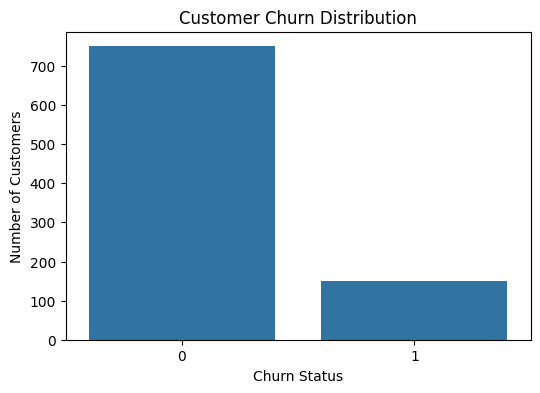

In [8]:
# Churn distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
# Churn percentage

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

churn_percentage

,proportion
Churn,
0,83.333333
1,16.666667


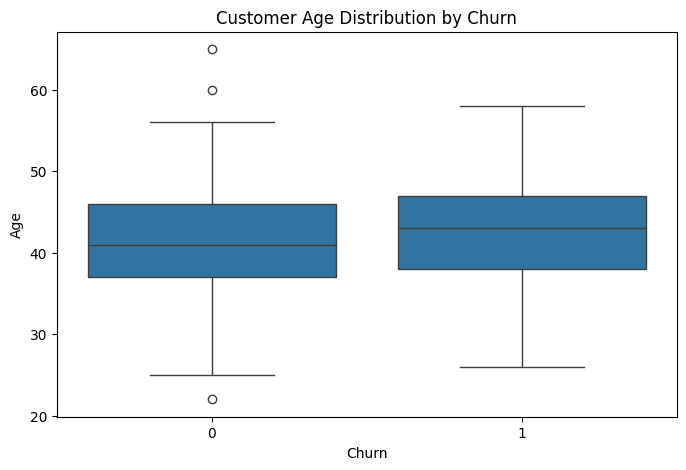

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Age"
)

plt.title("Customer Age Distribution by Churn")

plt.show()

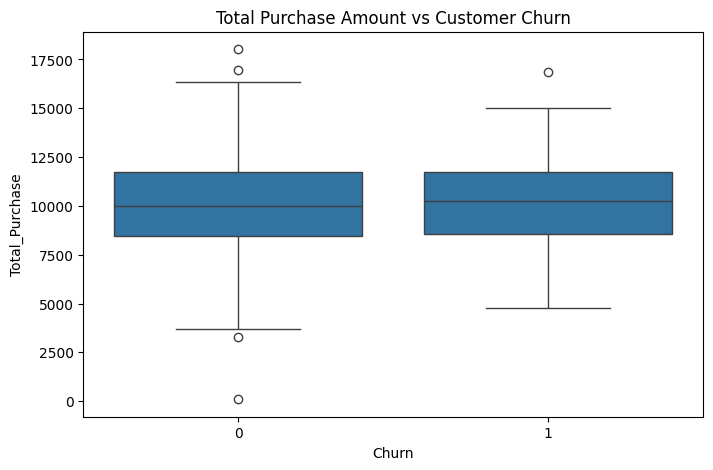

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Total_Purchase"
)

plt.title("Total Purchase Amount vs Customer Churn")

plt.show()

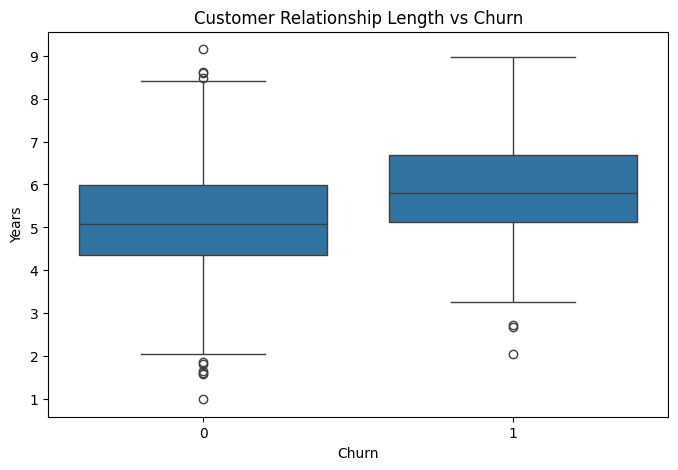

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Years"
)

plt.title("Customer Relationship Length vs Churn")

plt.show()

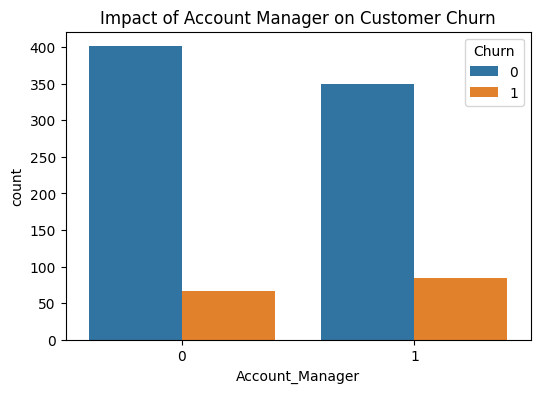

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Account_Manager",
    hue="Churn"
)

plt.title("Impact of Account Manager on Customer Churn")

plt.show()

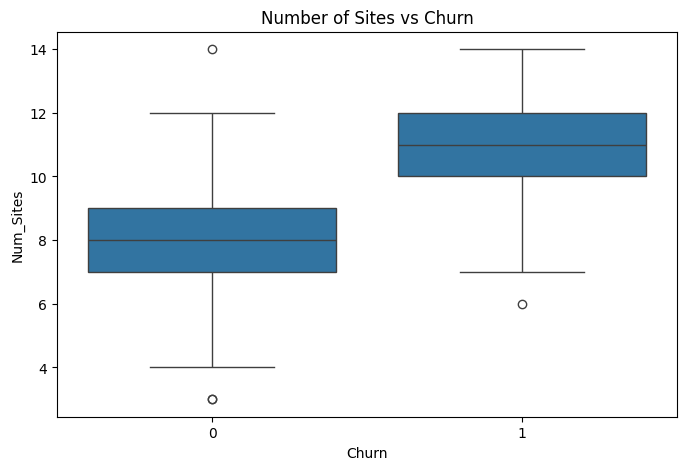

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Num_Sites"
)

plt.title("Number of Sites vs Churn")

plt.show()

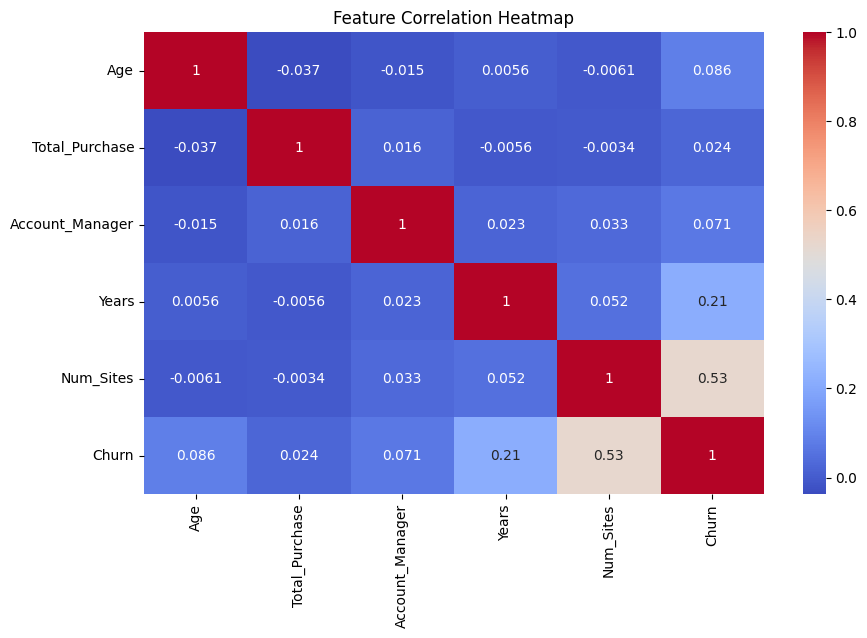

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

## 7. Feature Engineering

Feature engineering improves model performance by creating new meaningful variables from existing customer information.

New features created:

- Customer Value: Average purchase value based on customer lifetime
- Engagement Level: Customer activity category based on number of sites
- Customer Age Group: Age-based customer segmentation

These features help the model understand customer behavior better.

In [17]:
# Customer value based on total purchase and relationship duration

df["Customer_Value"] = df["Total_Purchase"] / df["Years"]

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Customer_Value
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,1532.797784
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,1833.264615
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,1931.746627
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,1193.853949
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,1653.161871


In [18]:
df[["Total_Purchase", "Years", "Customer_Value"]].head()

,Total_Purchase,Years,Customer_Value
0,11066.80,7.22,1532.797784
1,11916.22,6.50,1833.264615
2,12884.75,6.67,1931.746627
3,8010.76,6.71,1193.853949
4,9191.58,5.56,1653.161871


In [19]:
# Creating engagement groups based on number of sites

def engagement_category(sites):

    if sites <= 5:
        return "Low"

    elif sites <= 10:
        return "Medium"

    else:
        return "High"


df["Engagement_Level"] = df["Num_Sites"].apply(engagement_category)

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Customer_Value,Engagement_Level
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,1532.797784,Medium
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,1833.264615,High
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,1931.746627,High
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,1193.853949,Medium
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,1653.161871,Medium


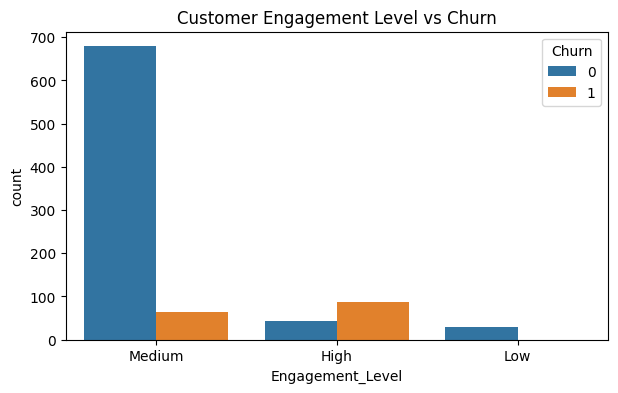

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Engagement_Level",
    hue="Churn"
)

plt.title("Customer Engagement Level vs Churn")

plt.show()

In [21]:
# Customer segmentation using age

def age_group(age):

    if age < 35:
        return "Young"

    elif age < 55:
        return "Middle"

    else:
        return "Senior"


df["Age_Group"] = df["Age"].apply(age_group)

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Customer_Value,Engagement_Level,Age_Group
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,1532.797784,Medium,Middle
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,1833.264615,High,Middle
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,1931.746627,High,Middle
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,1193.853949,Medium,Middle
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,1653.161871,Medium,Middle


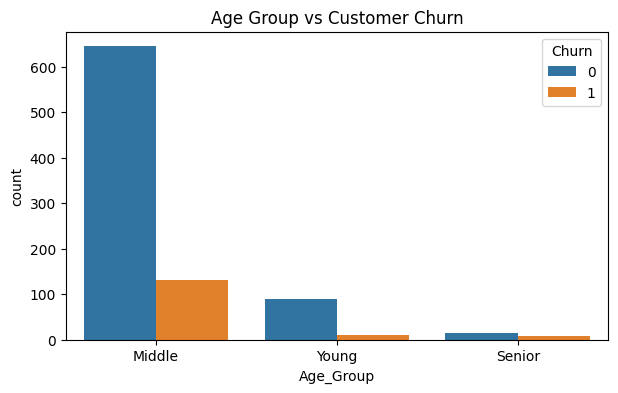

In [22]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Age_Group",
    hue="Churn"
)

plt.title("Age Group vs Customer Churn")

plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Names             900 non-null    object 
 1   Age               900 non-null    float64
 2   Total_Purchase    900 non-null    float64
 3   Account_Manager   900 non-null    int64  
 4   Years             900 non-null    float64
 5   Num_Sites         900 non-null    float64
 6   Onboard_date      900 non-null    object 
 7   Location          900 non-null    object 
 8   Company           900 non-null    object 
 9   Churn             900 non-null    int64  
 10  Customer_Value    900 non-null    float64
 11  Engagement_Level  900 non-null    object 
 12  Age_Group         900 non-null    object 
dtypes: float64(5), int64(2), object(6)
memory usage: 91.5+ KB


## 8. Data Preprocessing

Before training machine learning models, the dataset needs to be prepared.

Steps:

- Remove unnecessary columns
- Convert categorical variables
- Separate features and target variable
- Scale numerical values
- Split data into training and testing sets

In [24]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Customer_Value,Engagement_Level,Age_Group
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,1532.797784,Medium,Middle
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,1833.264615,High,Middle
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,1931.746627,High,Middle
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,1193.853949,Medium,Middle
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,1653.161871,Medium,Middle


In [29]:
df_model = df.drop(
    columns=[
        "Names",
        "Company",
        "Location",
        "Onboard_date"
    ]
)

df_model.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn,Customer_Value,Engagement_Level,Age_Group
0,42.0,11066.80,0,7.22,8.0,1,1532.797784,Medium,Middle
1,41.0,11916.22,0,6.50,11.0,1,1833.264615,High,Middle
2,38.0,12884.75,0,6.67,12.0,1,1931.746627,High,Middle
3,42.0,8010.76,0,6.71,10.0,1,1193.853949,Medium,Middle
4,37.0,9191.58,0,5.56,9.0,1,1653.161871,Medium,Middle


In [30]:
# Convert categorical variables

df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

df_model.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn,Customer_Value,Engagement_Level_Low,Engagement_Level_Medium,Age_Group_Senior,Age_Group_Young
0,42.0,11066.80,0,7.22,8.0,1,1532.797784,False,True,False,False
1,41.0,11916.22,0,6.50,11.0,1,1833.264615,False,False,False,False
2,38.0,12884.75,0,6.67,12.0,1,1931.746627,False,False,False,False
3,42.0,8010.76,0,6.71,10.0,1,1193.853949,False,True,False,False
4,37.0,9191.58,0,5.56,9.0,1,1653.161871,False,True,False,False


In [31]:
# Features and target

X = df_model.drop("Churn", axis=1)

y = df_model["Churn"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(720, 10)
(180, 10)


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Names             900 non-null    object 
 1   Age               900 non-null    float64
 2   Total_Purchase    900 non-null    float64
 3   Account_Manager   900 non-null    int64  
 4   Years             900 non-null    float64
 5   Num_Sites         900 non-null    float64
 6   Onboard_date      900 non-null    object 
 7   Location          900 non-null    object 
 8   Company           900 non-null    object 
 9   Churn             900 non-null    int64  
 10  Customer_Value    900 non-null    float64
 11  Engagement_Level  900 non-null    object 
 12  Age_Group         900 non-null    object 
dtypes: float64(5), int64(2), object(6)
memory usage: 91.5+ KB


## 9. Model Building and Comparison

Multiple machine learning models are trained and compared to identify the best performing model for customer churn prediction.

Models used:

- Logistic Regression
- Random Forest Classifier
- Gradient Boosting Classifier

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

In [36]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [37]:
results = []

for model_name, model in models.items():

    # Train model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test_scaled
    )

    y_prob = model.predict_proba(
        X_test_scaled
    )[:,1]


    results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )

    })


results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.922222,0.863636,0.633333,0.730769,0.888222
1,Random Forest,0.888889,0.750000,0.500000,0.600000,0.871889
2,Gradient Boosting,0.872222,0.666667,0.466667,0.549020,0.875111


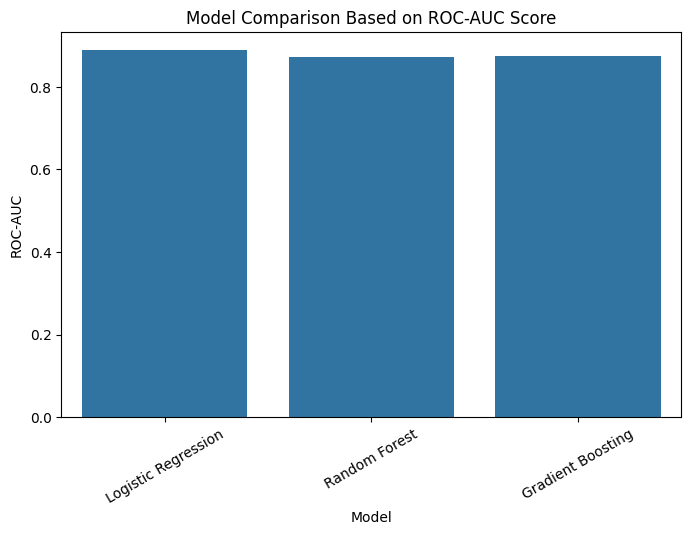

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model Comparison Based on ROC-AUC Score")

plt.xticks(rotation=30)

plt.show()

In [39]:
best_model = RandomForestClassifier(
    random_state=42
)

best_model.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

## 10. Final Model Evaluation

After comparing multiple machine learning models, the best model is evaluated in detail.

The evaluation includes:

- Classification report
- Confusion matrix
- ROC curve

These metrics help understand how well the model identifies customers who are likely to churn.

In [40]:
# Predict using final model

final_predictions = best_model.predict(
    X_test_scaled
)

final_probabilities = best_model.predict_proba(
    X_test_scaled
)[:,1]

In [41]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       150
           1       0.75      0.50      0.60        30

    accuracy                           0.89       180
   macro avg       0.83      0.73      0.77       180
weighted avg       0.88      0.89      0.88       180



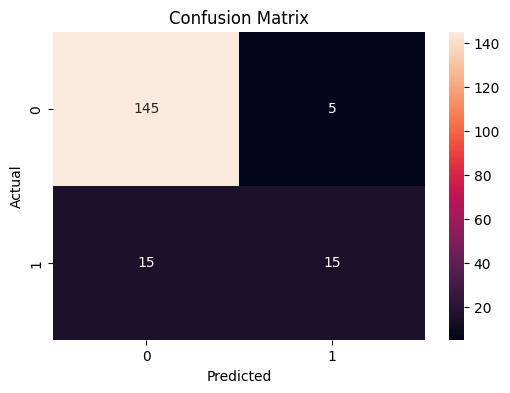

In [42]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

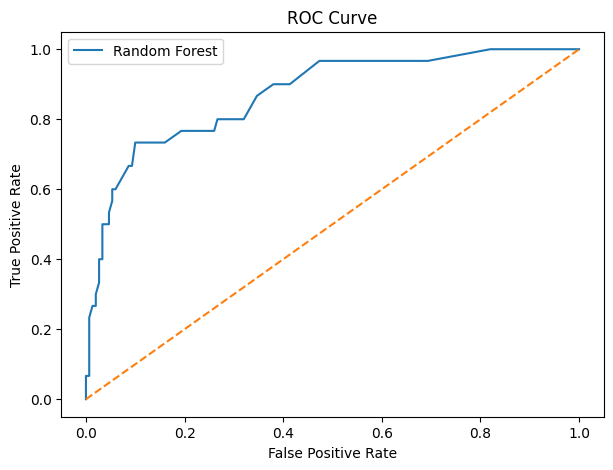

In [43]:
fpr, tpr, threshold = roc_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## 11. Feature Importance Analysis

Feature importance helps explain which customer attributes have the strongest impact on churn prediction.

This provides business insights for customer retention strategies.

In [44]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Num_Sites,0.240304
3,Years,0.194929
5,Customer_Value,0.152772
1,Total_Purchase,0.141103
0,Age,0.105294
7,Engagement_Level_Medium,0.105144
2,Account_Manager,0.025542
6,Engagement_Level_Low,0.018590
8,Age_Group_Senior,0.009491
9,Age_Group_Young,0.006832


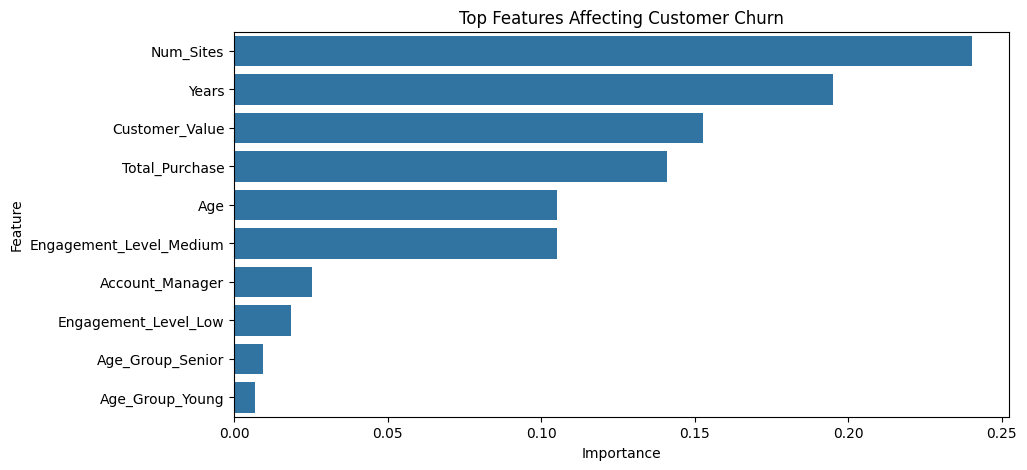

In [45]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Affecting Customer Churn")

plt.show()

## 12. Predicting Churn for New Customers

The trained machine learning model is used to predict churn risk for new customers.

The output helps businesses identify customers who need retention strategies.

In [47]:
new_customers = pd.read_csv(
    "/content/new_customers_1.csv"
)

new_customers.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC


In [48]:
new_data = new_customers.copy()


new_data["Customer_Value"] = (
    new_data["Total_Purchase"] /
    new_data["Years"]
)


new_data["Engagement_Level"] = (
    new_data["Num_Sites"]
    .apply(engagement_category)
)


new_data["Age_Group"] = (
    new_data["Age"]
    .apply(age_group)
)


new_data.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Customer_Value,Engagement_Level,Age_Group
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd,1288.654994,Medium,Middle
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson,811.092672,High,Young
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson,100.000000,High,Senior
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden,690.159574,High,Young
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC,1314.771000,Medium,Young


In [50]:
new_data = new_data.drop(
    columns=[
        "Names",
        "Company",
        "Location",
        "Onboard_date"
    ]
)


new_data = pd.get_dummies(
    new_data,
    drop_first=True
)

In [51]:
new_data = new_data.reindex(
    columns=X.columns,
    fill_value=0
)

In [52]:
new_data = new_data.reindex(
    columns=X.columns,
    fill_value=0
)

In [53]:
new_data_scaled = scaler.transform(
    new_data
)

In [54]:
churn_prediction = best_model.predict(
    new_data_scaled
)


churn_probability = best_model.predict_proba(
    new_data_scaled
)[:,1]

In [55]:
prediction_results = new_customers.copy()


prediction_results["Churn_Prediction"] = churn_prediction


prediction_results["Churn_Risk_%"] = (
    churn_probability * 100
).round(2)


prediction_results

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn_Prediction,Churn_Risk_%
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd,0,3.0
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson,1,77.0
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson,0,47.0
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden,1,63.0
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC,0,32.0
5,Jessica Drake,22.0,8445.26,1,3.46,14.0,2011-02-04 19:29:27,1148 Tina Stravenue Apt. 978 South Carlos TX 2...,Parks-Robbins,0,38.0


## 13. Conclusion and Business Insights

The customer churn prediction system successfully identifies customers who have a higher probability of leaving.

Key findings:

- Customer activity and relationship duration influence churn behavior.
- Machine learning models can identify high-risk customers before they leave.
- Businesses can focus retention campaigns on customers with higher churn probability.

Possible business actions:

- Provide special offers for high-risk customers.
- Improve customer engagement.
- Assign account managers to valuable customers.

Future improvements:

- Hyperparameter tuning
- More customer behavioral features
- Deployment using a web application